#  Qwen 2.5-7B Fine-Tuning Notebook

**Model:** Qwen 2.5-7B-Instruct (QLoRA 4-bit via Unsloth)    
**Tracking:** MLflow (SQLite backend)  
**Experiments:** 3 hyperparameter runs with full evaluation and leaderboard


## Cell 1 - Install Dependencies

In [ ]:
%%capture
import subprocess, sys, os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_ALLOC_CONF"]   = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"  




def run(cmd, check=False):
    subprocess.run([sys.executable, "-m", "pip"] + cmd, check=check)

# Step 1: Install Unsloth
run(["install",
     "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git",
     "--quiet"])

# Step 2: Pin transformers to 5.5.0 (max supported by unsloth-zoo <=5.5.0)
run(["install", "transformers==5.5.0", "--quiet"])

# Step 3: Uninstall torchaudio (circular import crashes transformers 5.x)
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torchaudio"],
               capture_output=True)

# Step 4: Remaining dependencies
run(["install",
     "mlflow", "rouge-score", "sacrebleu", "bert-score",
     "nltk", "evaluate", "seaborn", "scikit-learn", "--quiet"])

import nltk
nltk.download("wordnet",   quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

# Step 5: Patch PIL version mismatch

try:
    import PIL._imaging as _pil_core
    _core_ver = _pil_core.PILLOW_VERSION          
    import PIL
    PIL.__version__ = _core_ver                   
    import importlib, sys
    # Remove cached PIL.Image so it re-imports with the patched version
    for _mod in list(sys.modules.keys()):
        if _mod.startswith("PIL"):
            del sys.modules[_mod]
    import PIL
    PIL.__version__ = _core_ver
    from PIL import Image                         
    print(f"  Pillow patch applied: version pinned to {_core_ver} (core) OK")
except Exception as _e:
    print(f"  Pillow patch: {_e}")

# Verify versions
import importlib as _il
for pkg in ["unsloth", "transformers", "torch", "peft", "trl"]:
    try:
        m = _il.import_module(pkg)
        print(f"  {pkg}: {getattr(m, '__version__', 'ok')}")
    except Exception as e:
        print(f"  {pkg}: FAILED -> {e}")

try:
    import torchaudio; print(f"  torchaudio: {torchaudio.__version__} (WARNING)")
except ImportError:
    print("  torchaudio: uninstalled (OK)")

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

print("Setup complete.")


## Cell 2 - Imports

In [ ]:

try:
    import PIL._imaging as _pil_core
    import PIL as _pil_pkg
    _pil_pkg.__version__ = _pil_core.PILLOW_VERSION
except Exception:
    pass  

import os, json, time, random, gc, warnings
from pathlib import Path
from typing import Dict, List, Optional
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from transformers import TrainingArguments, TrainerCallback, set_seed
from peft import PeftModel
from trl  import SFTTrainer
from datasets import Dataset as HFDataset
import datasets as _ds_lib
_ds_lib.config.MAX_NUM_PROC = 2  

from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

from rouge_score       import rouge_scorer
from sacrebleu.metrics import BLEU
from bert_score        import score as bert_score_fn
import evaluate as hf_evaluate

import mlflow, mlflow.pytorch
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import seaborn             as sns
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split

print("Imports OK")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Imports OK
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## Cell 3 - Global Configuration

In [ ]:
SEED              = 42
MAX_SEQ_LENGTH    = 1024
MODEL_NAME        = "unsloth/Qwen2.5-7B-Instruct"   
MLFLOW_EXPERIMENT = "MediCare_Qwen25_7B_Finetuning"
EVAL_SAMPLES      = 300
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.80, 0.10, 0.10


## Cell 4 - Hyperparameter Experiments

In [ ]:


EXPERIMENTS = [
    {
        "run_name":                     "run_1_baseline",
        "description":                  "Baseline: lr=2e-4, r=16",
        "learning_rate":                2e-4,
        "lora_r":                       16,
        "lora_alpha":                   32,
        "lora_dropout":                 0.05,
        "per_device_train_batch_size":  1,
        "per_device_eval_batch_size":   1,
        "num_train_epochs":             3,
        "max_steps":                    100,  
        "weight_decay":                 0.01,
        "warmup_ratio":                 0.03,
        "gradient_accumulation_steps":  16,
        "lr_scheduler_type":            "cosine",
    },
    {
        "run_name":                     "run_2_high_rank",
        "description":                  "High rank: lr=1e-4, r=32",
        "learning_rate":                1e-4,
        "lora_r":                       32,
        "lora_alpha":                   64,
        "lora_dropout":                 0.10,
        "per_device_train_batch_size":  1,
        "per_device_eval_batch_size":   1,
        "num_train_epochs":             2,
        "max_steps":                    100,  
        "weight_decay":                 0.001,
        "warmup_ratio":                 0.05,
        "gradient_accumulation_steps":  16,
        "lr_scheduler_type":            "linear",
    },
    {
        "run_name":                     "run_3_conservative",
        "description":                  "Conservative: lr=5e-5, r=8",
        "learning_rate":                5e-5,
        "lora_r":                       8,
        "lora_alpha":                   16,
        "lora_dropout":                 0.0,
        "per_device_train_batch_size":  1,
        "per_device_eval_batch_size":   1,
        "num_train_epochs":             3,
        "max_steps":                    100,   
        "weight_decay":                 0.10,
        "warmup_ratio":                 0.10,
        "gradient_accumulation_steps":  16,
        "lr_scheduler_type":            "cosine",
    },
]
print(f"Defined {len(EXPERIMENTS)} experiments  |  total steps: {sum(e['max_steps'] for e in EXPERIMENTS)}")


Defined 3 experiments  |  total steps: 300


## Cell 5 - Auto-Discover and Load Dataset

In [ ]:
import subprocess

def find_dataset_files() -> List[str]:
    """Auto-discover all .jsonl files under /kaggle/input/ regardless of path."""
    result = subprocess.run(
        ["find", "/kaggle/input", "-name", "*.jsonl", "-type", "f"],
        capture_output=True, text=True
    )
    all_jsonl = sorted(result.stdout.strip().splitlines())

    if not all_jsonl:
        raise FileNotFoundError(
            "\nNo .jsonl files found under /kaggle/input/\n"
            "Make sure you attached your dataset via 'Add Data' in the Kaggle notebook UI."
        )

    print(f"Found {len(all_jsonl)} .jsonl file(s):")
    for p in all_jsonl:
        size_mb = Path(p).stat().st_size / 1e6
        print(f"  {p}  ({size_mb:.1f} MB)")

    
    merged = [p for p in all_jsonl if "finetune_qwen_final" in p]
    if merged:
        print(f"\nUsing merged file: {merged[0]}")
        return merged

    batches = sorted([p for p in all_jsonl if "batch" in Path(p).name])
    if batches:
        print(f"\nUsing {len(batches)} batch file(s)")
        return batches

    print(f"\nUsing all {len(all_jsonl)} file(s)")
    return all_jsonl


def load_jsonl_dataset(paths: List[str]) -> List[Dict]:
    data = []
    for path in paths:
        p = Path(path)
        print(f"  Loading {p.name}  ({p.stat().st_size/1e6:.1f} MB)...")
        with open(p, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        data.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
    return data


dataset_files = find_dataset_files()
raw_data      = load_jsonl_dataset(dataset_files)
print(f"\nTotal examples loaded: {len(raw_data):,}")


Found 1 .jsonl file(s):
  /kaggle/input/datasets/rahma123456y/qwentraining/finetune_qwen_final.jsonl  (92.7 MB)

Using merged file: /kaggle/input/datasets/rahma123456y/qwentraining/finetune_qwen_final.jsonl
  Loading finetune_qwen_final.jsonl  (92.7 MB)...

Total examples loaded: 54,000


## Cell 6 - Dataset Exploration

In [7]:
from collections import Counter
intents, langs = Counter(), Counter()

for item in raw_data:
    for conv in item.get("conversations", []):
        if conv["from"] == "human":
            try:
                inp = json.loads(conv["value"])
                intents[inp.get("intent",   "?")] += 1
                langs[inp.get("language", "?")] += 1
            except Exception:
                pass

print("Dataset Statistics")
print("-" * 50)
print(f"  Total examples : {len(raw_data):,}")
print(f"\n  Language split:")
for lang, cnt in sorted(langs.items()):
    print(f"    {lang:5s}: {cnt:6,}  ({cnt/len(raw_data)*100:.1f}%)")
print(f"\n  Intent distribution:")
for intent, cnt in intents.most_common(18):
    print(f"    {intent:30s}: {cnt:5,}")

print("\nSample Example")
print("-" * 50)
sample = raw_data[0]
for conv in sample["conversations"]:
    print(f"\n[{conv['from'].upper()}]")
    val = conv["value"]
    if conv["from"] == "human":
        try:
            d = json.loads(val)
            print(f"  user_message   : {d.get('user_message','')[:80]}")
            print(f"  intent         : {d.get('intent','')}")
            print(f"  language       : {d.get('language','')}")
            recs = d.get("recommendations", [])
            if recs:
                print(f"  recommendations: {[r['product_name'] for r in recs[:2]]}")
        except Exception:
            print(f"  {val[:100]}")
    else:
        print(f"  {val[:120]}...")


Dataset Statistics
--------------------------------------------------
  Total examples : 54,000

  Language split:
    ar   : 27,000  (50.0%)
    en   : 27,000  (50.0%)

  Intent distribution:
    memory_check                  : 3,000
    return                        : 3,000
    goodbye                       : 3,000
    product_details               : 3,000
    recommendation_reasoning      : 3,000
    purchase                      : 3,000
    recommendation_request        : 3,000
    confirmation                  : 3,000
    greeting                      : 3,000
    inquiry                       : 3,000
    payment                       : 3,000
    product_search                : 3,000
    feedback                      : 3,000
    order_tracking                : 3,000
    complaint                     : 3,000
    support                       : 3,000
    offer                         : 3,000
    introduce_name                : 3,000

Sample Example
-----------------------------------

## Cell 7 - Preprocess to ShareGPT Format

In [8]:
def convert_to_messages(example: Dict) -> Optional[List[Dict]]:
    role_map = {"system": "system", "human": "user", "gpt": "assistant"}
    messages = []
    for conv in example.get("conversations", []):
        role = role_map.get(conv.get("from", ""))
        if role:
            messages.append({"role": role, "content": conv.get("value", "")})
    roles = {m["role"] for m in messages}
    if "user" not in roles or "assistant" not in roles:
        return None
    return messages

def get_ground_truth(example: Dict) -> str:
    for conv in example.get("conversations", []):
        if conv.get("from") == "gpt":
            return conv.get("value", "")
    return ""

def get_input_ctx(example: Dict) -> Dict:
    for conv in example.get("conversations", []):
        if conv.get("from") == "human":
            try:
                return json.loads(conv.get("value", "{}"))
            except Exception:
                return {}
    return {}

print("Converting to Qwen message format...")
processed, skipped = [], 0

for item in tqdm(raw_data, desc="Processing"):
    msgs = convert_to_messages(item)
    if msgs is None:
        skipped += 1
        continue
    ctx = get_input_ctx(item)
    processed.append({
        "messages":     msgs,
        "ground_truth": get_ground_truth(item),
        "intent":       ctx.get("intent",       "unknown"),
        "language":     ctx.get("language",     "en"),
        "user_message": ctx.get("user_message", ""),
    })

print(f"Processed : {len(processed):,}")
print(f"Skipped   : {skipped:,}")


Converting to Qwen message format...


Processing:   0%|          | 0/54000 [00:00<?, ?it/s]

Processed : 54,000
Skipped   : 0


## Cell 8 - Train / Val / Test Split

In [9]:
set_seed(SEED)

train_val, test_data = train_test_split(
    processed, test_size=TEST_RATIO, random_state=SEED, shuffle=True
)
val_adj = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_data, val_data = train_test_split(
    train_val, test_size=val_adj, random_state=SEED, shuffle=True
)

print("Dataset Split")
print("-" * 40)
print(f"  Training   : {len(train_data):,}  ({len(train_data)/len(processed)*100:.0f}%)")
print(f"  Validation : {len(val_data):,}   ({len(val_data)/len(processed)*100:.0f}%)")
print(f"  Test       : {len(test_data):,}   ({len(test_data)/len(processed)*100:.0f}%)")

eval_val_data  = random.sample(val_data,  min(EVAL_SAMPLES, len(val_data)))
eval_test_data = random.sample(test_data, min(EVAL_SAMPLES, len(test_data)))
print(f"\nEval subsets: val={len(eval_val_data)}, test={len(eval_test_data)}")


def create_hf_dataset(data: List[Dict], tokenizer) -> HFDataset:
    texts = [
        tokenizer.apply_chat_template(
            item["messages"], tokenize=False, add_generation_prompt=False
        )
        for item in data
    ]
    return HFDataset.from_dict({"text": texts})

print("HF Dataset helper defined")


Dataset Split
----------------------------------------
  Training   : 43,200  (80%)
  Validation : 5,400   (10%)
  Test       : 5,400   (10%)

Eval subsets: val=300, test=300
HF Dataset helper defined


## Cell 9 - Load Model and Tokenizer

In [ ]:
# --- Kaggle internet check ---
import urllib.request
def _check_internet():
    try:
        urllib.request.urlopen("https://huggingface.co", timeout=5)
        return True
    except Exception:
        return False

if not _check_internet():
    raise RuntimeError(
        "\nNo internet access detected.\n"
        "Kaggle Notebook Settings -> Internet -> ON, then Restart & Run All.\n"
    )
print("Internet: OK")


from kaggle_secrets import UserSecretsClient
_hf_token = None
try:
    _hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    from huggingface_hub import login as hf_login
    hf_login(token=_hf_token, add_to_git_credential=False)
    print("HuggingFace: logged in via HF_TOKEN")
except Exception as e:
    print(f"HuggingFace: no secret ({e}). Using anonymous access.")

import unsloth, transformers, torch
print(f"Versions: unsloth={unsloth.__version__}  transformers={transformers.__version__}  torch={torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}  |  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

import gc
gc.collect()
torch.cuda.empty_cache()
TRAINING_GPU = 0   # single-GPU mode (CUDA_VISIBLE_DEVICES=0 set in Cell 1)
print(f"Training GPU: {TRAINING_GPU}  |  Free VRAM: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0))/1e9:.2f} GB")


# NOTE: Qwen2.5 has no 5B model. Sizes: 0.5B 1.5B 3B 7B 14B 32B 72B
MODEL_CANDIDATES = [
    "unsloth/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "unsloth/Qwen2.5-3B-Instruct",
]

def _apply_lora_unsloth(m, lora_r, lora_alpha, lora_dropout):
    """Try Unsloth's get_peft_model with progressively simpler kwargs."""
    kwargs_options = [
        # Full kwargs
        dict(r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
             target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
             bias="none", use_gradient_checkpointing="unsloth",
             random_state=SEED, use_rslora=False, loftq_config=None),
        # Without loftq_config / use_rslora (deprecated in newer Unsloth)
        dict(r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
             target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
             bias="none", use_gradient_checkpointing=True, random_state=SEED),
        # Minimal
        dict(r=lora_r, lora_alpha=lora_alpha,
             target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
             bias="none"),
    ]
    for kw in kwargs_options:
        try:
            result = FastLanguageModel.get_peft_model(m, **kw)
            print(f"   Unsloth LoRA applied (kwargs={list(kw.keys())})")
            return result
        except Exception as e:
            print(f"   Unsloth get_peft_model failed ({e}), trying simpler kwargs...")
    raise RuntimeError("Unsloth get_peft_model failed with all kwarg combinations.")

def _apply_lora_peft(m, lora_r, lora_alpha, lora_dropout):
    """Fallback: standard PEFT LoRA (works with any transformers version)."""
    from peft import LoraConfig, get_peft_model, TaskType
    config = LoraConfig(
        r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
        target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
        bias="none", task_type=TaskType.CAUSAL_LM,
    )
    result = get_peft_model(m, config)
    m.enable_input_require_grads()
    print("   Standard PEFT LoRA applied (Unsloth get_peft_model fallback).")
    return result

def load_model_and_tokenizer(lora_r: int = 16, lora_alpha: int = 32, lora_dropout: float = 0.05):
    global MODEL_NAME
    last_error = None
    for model_name in MODEL_CANDIDATES:
        try:
            print(f"\nTrying: {model_name} ...")
            m, tok = FastLanguageModel.from_pretrained(
                model_name        = model_name,
                max_seq_length    = MAX_SEQ_LENGTH,
                dtype             = None,
                load_in_4bit      = True,
                device_map        = {"": TRAINING_GPU},
                token             = _hf_token,
            )
            MODEL_NAME = model_name
            print(f"Base model loaded: {MODEL_NAME}")
            break
        except Exception as e:
            print(f"  Failed to load base model: {e}")
            last_error = e
    else:
        raise RuntimeError(f"All model candidates failed.\nLast error: {last_error}")

    # Apply LoRA — try Unsloth first, fall back to standard PEFT
    try:
        m = _apply_lora_unsloth(m, lora_r, lora_alpha, lora_dropout)
    except Exception as e:
        print(f"   Unsloth LoRA completely failed ({e}). Using standard PEFT fallback.")
        m = _apply_lora_peft(m, lora_r, lora_alpha, lora_dropout)

    print(f"   Trainable: {sum(p.numel() for p in m.parameters() if p.requires_grad):,} params")
    return m, tok

MODEL_NAME = None
print('load_model_and_tokenizer() ready  |  training GPU:', TRAINING_GPU)


Internet: OK
HuggingFace: no secret (Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 123407349 and label HF_TOKEN.'], 'error': {'code': 5}, 'wasSuccessful': False}.). Using anonymous access.
Versions: unsloth=2026.6.7  transformers=5.5.0  torch=2.10.0+cu128
CUDA: True  |  GPU: Tesla T4
Training GPU: 0  |  Free VRAM: 15.62 GB
load_model_and_tokenizer() ready  |  training GPU: 0


## Cell 10 - MLflow Setup (SQLite Backend)

In [11]:
# SQLite backend -- required in MLflow >= 2.13 (filesystem backend deprecated)
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
if exp is None:
    experiment_id = mlflow.create_experiment(
        MLFLOW_EXPERIMENT,
        tags={"model": "Qwen2.5-7B", "task": "SFT", "dataset": "MediCare-AI"}
    )
else:
    experiment_id = exp.experiment_id

mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow experiment : '{MLFLOW_EXPERIMENT}' (ID: {experiment_id})")
print(f"Tracking URI      : {MLFLOW_TRACKING_URI}")


class MLflowCallback(TrainerCallback):
    """Logs step-level metrics to the already-active MLflow run.
    Uses nested=True so it never conflicts with the parent run opened
    in run_experiment() via `with mlflow.start_run(...) as run`.
    """
    def __init__(self, run_id: str):
        self.run_id  = run_id
        self.t_start = time.time()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        # Use nested=True to safely log inside the already-active parent run
        with mlflow.start_run(run_id=self.run_id, nested=True):
            for k, v in logs.items():
                if isinstance(v, (int, float)):
                    mlflow.log_metric(k, v, step=state.global_step)
            if torch.cuda.is_available():
                mlflow.log_metric(
                    "gpu_memory_gb",
                    torch.cuda.memory_allocated() / 1e9,
                    step=state.global_step,
                )

    def on_train_end(self, args, state, control, **kwargs):
        elapsed = time.time() - self.t_start
        with mlflow.start_run(run_id=self.run_id, nested=True):
            mlflow.log_metric("total_training_time_sec", elapsed)
        print(f"   Training done in {elapsed/60:.1f} min")

print("MLflow callback defined")


2026/06/17 11:27:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 11:27:18 INFO mlflow.store.db.utils: Updating database tables


MLflow experiment : 'MediCare_Qwen25_7B_Finetuning' (ID: 1)
Tracking URI      : sqlite:///mlflow.db
MLflow callback defined


## Cell 11 - Evaluation Functions

In [12]:
def compute_perplexity(model, tokenizer, texts: List[str], max_texts: int = 80) -> float:
    model.eval()
    total_loss, total_tokens = 0.0, 0
    batch_size = 4
    with torch.no_grad():
        for i in range(0, min(len(texts), max_texts), batch_size):
            batch = texts[i : i + batch_size]
            enc   = tokenizer(batch, return_tensors="pt", padding=True,
                              truncation=True, max_length=512).to(model.device)
            labels = enc["input_ids"].clone()
            labels[labels == tokenizer.pad_token_id] = -100
            out = model(**enc, labels=labels)
            n_tok         = (labels != -100).sum().item()
            total_loss   += out.loss.item() * n_tok
            total_tokens += n_tok
    return float(np.exp(total_loss / max(total_tokens, 1)))


def compute_token_accuracy(model, tokenizer, examples: List[Dict], max_samples: int = 40) -> float:
    model.eval()
    correct, total = 0, 0
    for item in examples[:max_samples]:
        text   = tokenizer.apply_chat_template(item["messages"], tokenize=False, add_generation_prompt=False)
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
        with torch.no_grad():
            out    = model(**inputs)
            logits = out.logits[:, :-1, :]
            labels = inputs["input_ids"][:, 1:]
            preds  = logits.argmax(dim=-1)
            mask   = labels != tokenizer.pad_token_id
            correct += (preds == labels)[mask].sum().item()
            total   += mask.sum().item()
    return correct / max(total, 1)


def generate_predictions(model, tokenizer, examples: List[Dict], max_new_tokens: int = 256) -> List[str]:
    FastLanguageModel.for_inference(model)
    predictions = []
    for item in tqdm(examples, desc="Generating", leave=False):
        msgs_no_resp = [m for m in item["messages"] if m["role"] != "assistant"]
        prompt = tokenizer.apply_chat_template(msgs_no_resp, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)
        with torch.no_grad():
            out_ids = model.generate(
                **inputs,
                max_new_tokens     = max_new_tokens,
                do_sample          = False,
                repetition_penalty = 1.1,
                pad_token_id       = tokenizer.eos_token_id,
            )
        new_toks = out_ids[0][inputs["input_ids"].shape[1]:]
        predictions.append(tokenizer.decode(new_toks, skip_special_tokens=True).strip())
    FastLanguageModel.for_training(model)
    return predictions


def compute_all_metrics(predictions: List[str], references: List[str]) -> Dict[str, float]:
    pairs = [(p, r) for p, r in zip(predictions, references) if p.strip() and r.strip()]
    if not pairs:
        return {}
    preds, refs = map(list, zip(*pairs))
    metrics = {}

    try:
        sc = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
        r1, r2, rL = [], [], []
        for p, r in zip(preds, refs):
            s = sc.score(r, p)
            r1.append(s["rouge1"].fmeasure); r2.append(s["rouge2"].fmeasure); rL.append(s["rougeL"].fmeasure)
        metrics.update(rouge1=float(np.mean(r1)), rouge2=float(np.mean(r2)), rougeL=float(np.mean(rL)))
        print(f"   ROUGE: R1={metrics['rouge1']:.4f}  R2={metrics['rouge2']:.4f}  RL={metrics['rougeL']:.4f}")
    except Exception as e:
        print(f"   ROUGE error: {e}"); metrics.update(rouge1=0.0, rouge2=0.0, rougeL=0.0)

    try:
        metrics["bleu"] = float(BLEU(effective_order=True).corpus_score(preds, [refs]).score / 100)
        print(f"   BLEU: {metrics['bleu']:.4f}")
    except Exception as e:
        print(f"   BLEU error: {e}"); metrics["bleu"] = 0.0

    try:
        metrics["meteor"] = float(hf_evaluate.load("meteor").compute(predictions=preds, references=refs)["meteor"])
        print(f"   METEOR: {metrics['meteor']:.4f}")
    except Exception as e:
        print(f"   METEOR error: {e}"); metrics["meteor"] = 0.0

    try:
        _, _, F1 = bert_score_fn(preds, refs, model_type="bert-base-multilingual-cased", verbose=False)
        metrics["bert_score"] = float(F1.mean().item())
        print(f"   BERTScore F1: {metrics['bert_score']:.4f}")
    except Exception as e:
        print(f"   BERTScore error: {e}"); metrics["bert_score"] = 0.0

    metrics["exact_match"] = float(sum(p.strip() == r.strip() for p, r in zip(preds, refs)) / len(preds))
    print(f"   Exact Match: {metrics['exact_match']:.4f}")
    return metrics

print("Evaluation functions defined")


Evaluation functions defined


## Cell 12 - Training Function

In [ ]:
def _make_training_args(config: Dict, output_dir: str) -> TrainingArguments:
    """Build TrainingArguments, dropping any kwargs removed in newer transformers."""
    base_kwargs = dict(
        output_dir                  = output_dir,
        num_train_epochs            = config["num_train_epochs"],
        per_device_train_batch_size = config["per_device_train_batch_size"],
        per_device_eval_batch_size  = 2,
        gradient_accumulation_steps = config["gradient_accumulation_steps"],
        learning_rate               = config["learning_rate"],
        weight_decay                = config["weight_decay"],
        warmup_ratio                = config["warmup_ratio"],
        lr_scheduler_type           = config.get("lr_scheduler_type", "cosine"),
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        logging_steps               = 10,
        eval_steps                   = 50,
        save_steps                   = 9999,   
        eval_strategy               = "steps",
        save_strategy               = "no",     
        load_best_model_at_end      = False,  
        
        report_to                   = "none",
        seed                        = SEED,
        dataloader_num_workers      = 0,
        optim                       = "adamw_8bit",
        max_grad_norm               = 1.0,
        max_steps                   = config.get("max_steps", -1),
    )
    
    optional_kwargs = {"group_by_length": True}  
    for key, val in optional_kwargs.items():
        try:
            TrainingArguments(**{**base_kwargs, key: val})
            base_kwargs[key] = val
        except TypeError:
            pass  
    return TrainingArguments(**base_kwargs)


def _make_sft_trainer(model, tokenizer, train_ds, val_ds, training_args, run_id):
    """Build SFTTrainer, adapting to API changes across TRL versions."""
    base_kwargs = dict(
        model              = model,
        tokenizer          = tokenizer,
        train_dataset      = train_ds,
        eval_dataset       = val_ds,
        args               = training_args,
        callbacks          = [MLflowCallback(run_id=run_id)],
    )
    
    optional = {
        "dataset_text_field": "text",
        "max_seq_length":     MAX_SEQ_LENGTH,
        "dataset_num_proc":   2,
        "packing":            False,
    }
    for key, val in optional.items():
        try:
            SFTTrainer(**{**base_kwargs, key: val})
            base_kwargs[key] = val
        except TypeError:
            pass
    return SFTTrainer(**base_kwargs)


def run_experiment(config: Dict, train_data: List[Dict], val_data: List[Dict], eval_val_data: List[Dict]) -> Dict:
    run_name = config["run_name"]
    print(f"\n{'='*60}\nStarting: {run_name}  |  {config.get('description','')}\n{'='*60}")
    set_seed(SEED)

    model, tokenizer = load_model_and_tokenizer(config["lora_r"], config["lora_alpha"], config["lora_dropout"])
    train_ds = create_hf_dataset(train_data, tokenizer)
    val_ds   = create_hf_dataset(val_data,   tokenizer)
    print(f"   train={len(train_ds):,}  val={len(val_ds):,}")

    output_dir = f"./checkpoints/{run_name}"
    os.makedirs(output_dir, exist_ok=True)

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id

        mlflow.log_params({
            "model_name":                   MODEL_NAME,
            "learning_rate":                config["learning_rate"],
            "lora_r":                       config["lora_r"],
            "lora_alpha":                   config["lora_alpha"],
            "lora_dropout":                 config["lora_dropout"],
            "per_device_train_batch_size":  config["per_device_train_batch_size"],
            "num_train_epochs":             config["num_train_epochs"],
            "weight_decay":                 config["weight_decay"],
            "warmup_ratio":                 config["warmup_ratio"],
            "gradient_accumulation_steps":  config["gradient_accumulation_steps"],
            "lr_scheduler_type":            config.get("lr_scheduler_type","cosine"),
            "max_seq_length":               MAX_SEQ_LENGTH,
            "seed":                         SEED,
            "train_samples":                len(train_data),
            "val_samples":                  len(val_data),
        })

        training_args = _make_training_args(config, output_dir)
        trainer = _make_sft_trainer(model, tokenizer, train_ds, val_ds, training_args, run_id)

        t0            = time.time()
        train_result  = trainer.train()
        training_time = time.time() - t0

        mlflow.log_metrics({
            "final_train_loss":   train_result.metrics.get("train_loss", 0.0),
            "training_time_sec":  training_time,
            "training_time_min":  training_time / 60,
            "samples_per_second": train_result.metrics.get("train_samples_per_second", 0.0),
        })
        if torch.cuda.is_available():
            mlflow.log_metric("peak_gpu_mem_gb", torch.cuda.max_memory_allocated() / 1e9)

        # val_loss from log_history 
        val_loss = next(
            (e["eval_loss"] for e in reversed(trainer.state.log_history) if "eval_loss" in e),
            float("inf")
        )
        mlflow.log_metric("val_loss", val_loss)
        print(f"   Val loss: {val_loss:.4f}")

        print("   Computing perplexity...")
        val_texts = [tokenizer.apply_chat_template(item["messages"], tokenize=False, add_generation_prompt=False)
                     for item in eval_val_data[:60]]
        perplexity = compute_perplexity(model, tokenizer, val_texts)
        mlflow.log_metric("perplexity", perplexity)
        print(f"   Perplexity: {perplexity:.2f}")

        print("   Computing token accuracy...")
        token_acc = compute_token_accuracy(model, tokenizer, eval_val_data, max_samples=30)
        mlflow.log_metric("token_accuracy", token_acc)
        print(f"   Token Accuracy: {token_acc:.4f}")

        print("   Generating predictions...")
        predictions   = generate_predictions(model, tokenizer, eval_val_data, max_new_tokens=200)
        ground_truths = [item["ground_truth"] for item in eval_val_data]

        print("   Computing NLP metrics...")
        nlp_metrics = compute_all_metrics(predictions, ground_truths)
        mlflow.log_metrics({
            "val_rouge1":      nlp_metrics.get("rouge1",      0.0),
            "val_rouge2":      nlp_metrics.get("rouge2",      0.0),
            "val_rougeL":      nlp_metrics.get("rougeL",      0.0),
            "val_bleu":        nlp_metrics.get("bleu",        0.0),
            "val_meteor":      nlp_metrics.get("meteor",      0.0),
            "val_bert_score":  nlp_metrics.get("bert_score",  0.0),
            "val_exact_match": nlp_metrics.get("exact_match", 0.0),
        })

        ckpt_path = f"{output_dir}/final_adapter"
        model.save_pretrained(ckpt_path)
        tokenizer.save_pretrained(ckpt_path)
        mlflow.log_artifact(ckpt_path)
        print(f"   Checkpoint: {ckpt_path}")

        results = {
            "run_name": run_name, "run_id": run_id, "config": config,
            "val_loss": val_loss, "perplexity": perplexity, "token_accuracy": token_acc,
            "training_time": training_time, "train_history": trainer.state.log_history,
            "predictions": predictions, "ground_truths": ground_truths,
            "checkpoint_path": ckpt_path,
            **{f"val_{k}": v for k, v in nlp_metrics.items()},
        }
        mlflow.log_dict(
            {k: v for k, v in results.items() if k not in ("predictions","ground_truths","train_history")},
            "results_summary.json"
        )

    print(f"\nCompleted: '{run_name}'  |  Val={val_loss:.4f}  PPL={perplexity:.2f}  BERT={nlp_metrics.get('bert_score',0):.4f}")
    del model, tokenizer, trainer
    gc.collect(); torch.cuda.empty_cache()
    return results

print("run_experiment() defined")


run_experiment() defined


## Cell 13 - Run All Experiments

In [14]:
all_results = []
for config in EXPERIMENTS:
    result = run_experiment(config, train_data, val_data, eval_val_data)
    all_results.append(result)
    print(f"\nCompleted: {config['run_name']}\n" + "-"*60)
print(f"\nAll {len(all_results)} experiments complete!")



Starting: run_1_baseline  |  Baseline: lr=2e-4, r=16

Trying: unsloth/Qwen2.5-7B-Instruct ...
==((====))==  Unsloth 2026.6.7: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

   Training done in 119.8 min
   Val loss: 0.5657
   Computing perplexity...
   Perplexity: 1.78
   Computing token accuracy...
   Token Accuracy: 0.8604
   Generating predictions...


Generating:   0%|          | 0/300 [00:00<?, ?it/s]

   Computing NLP metrics...
   ROUGE: R1=0.2940  R2=0.1691  RL=0.2601
   BLEU: 0.1552
   METEOR: 0.2881


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   BERTScore F1: 0.7240
   Exact Match: 0.0000
   Checkpoint: ./checkpoints/run_3_conservative/final_adapter

Completed: 'run_3_conservative'  |  Val=0.5657  PPL=1.78  BERT=0.7240

Completed: run_3_conservative
------------------------------------------------------------

All 3 experiments complete!


## Cell 14 - Leaderboard and Ranking

In [15]:
def compute_ranking_score(r: Dict) -> float:
    bert   = r.get("val_bert_score", 0)
    rougeL = r.get("val_rougeL",     0)
    bleu   = r.get("val_bleu",       0)
    meteor = r.get("val_meteor",     0)
    ppl    = r.get("perplexity",   100)
    vloss  = r.get("val_loss",      10)
    return (
        0.30 * bert + 0.20 * rougeL + 0.15 * bleu + 0.10 * meteor +
        0.15 * min(10 / max(ppl, 0.001), 1.0) +
        0.10 * min( 5 / max(vloss, 0.001), 1.0)
    )

rows = []
for r in all_results:
    score = compute_ranking_score(r)
    rows.append({
        "Run": r["run_name"], "Run ID": r["run_id"][:8] + "...",
        "LR": r["config"]["learning_rate"], "LoRA r": r["config"]["lora_r"],
        "LoRA alpha": r["config"]["lora_alpha"], "Batch": r["config"]["per_device_train_batch_size"],
        "Epochs": r["config"]["num_train_epochs"], "Weight Decay": r["config"]["weight_decay"],
        "Warmup": r["config"]["warmup_ratio"], "Grad Acc": r["config"]["gradient_accumulation_steps"],
        "Scheduler": r["config"].get("lr_scheduler_type","cosine"),
        "Val Loss":         round(r["val_loss"],              4),
        "Perplexity":       round(r["perplexity"],            2),
        "Token Acc":        round(r.get("token_accuracy",     0), 4),
        "ROUGE-1":          round(r.get("val_rouge1",         0), 4),
        "ROUGE-2":          round(r.get("val_rouge2",         0), 4),
        "ROUGE-L":          round(r.get("val_rougeL",         0), 4),
        "BLEU":             round(r.get("val_bleu",           0), 4),
        "METEOR":           round(r.get("val_meteor",         0), 4),
        "BERTScore":        round(r.get("val_bert_score",     0), 4),
        "Exact Match":      round(r.get("val_exact_match",    0), 4),
        "Train Time (min)": round(r["training_time"] / 60,       1),
        "Ranking Score":    round(score,                          4),
    })

rows.sort(key=lambda x: x["Ranking Score"], reverse=True)
for i, row in enumerate(rows):
    row["Rank"] = i + 1

leaderboard_df = pd.DataFrame(rows)
print("EXPERIMENT LEADERBOARD\n" + "="*80)
display(leaderboard_df)
leaderboard_df.to_csv("leaderboard.csv", index=False)
print("\nSaved: leaderboard.csv")

with mlflow.start_run(run_name="leaderboard"):
    mlflow.log_artifact("leaderboard.csv")


EXPERIMENT LEADERBOARD


,Run,Run ID,LR,LoRA r,LoRA alpha,Batch,Epochs,Weight Decay,Warmup,Grad Acc,...,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,METEOR,BERTScore,Exact Match,Train Time (min),Ranking Score,Rank
0,run_1_baseline,0edd2fba...,0.00020,16,32,1,3,0.010,0.03,16,...,0.6884,0.5765,0.6527,0.5940,0.7017,0.8714,0.2533,120.9,0.8012,1
1,run_2_high_rank,14d14c57...,0.00010,32,64,1,2,0.001,0.05,16,...,0.6802,0.5624,0.6550,0.5781,0.6885,0.8664,0.2167,121.5,0.7965,2
2,run_3_conservative,58d004fe...,0.00005,8,16,1,3,0.100,0.10,16,...,0.2940,0.1691,0.2601,0.1552,0.2881,0.7240,0.0000,114.6,0.5713,3



Saved: leaderboard.csv


## Cell 15 - 9-Panel Visualization Dashboard

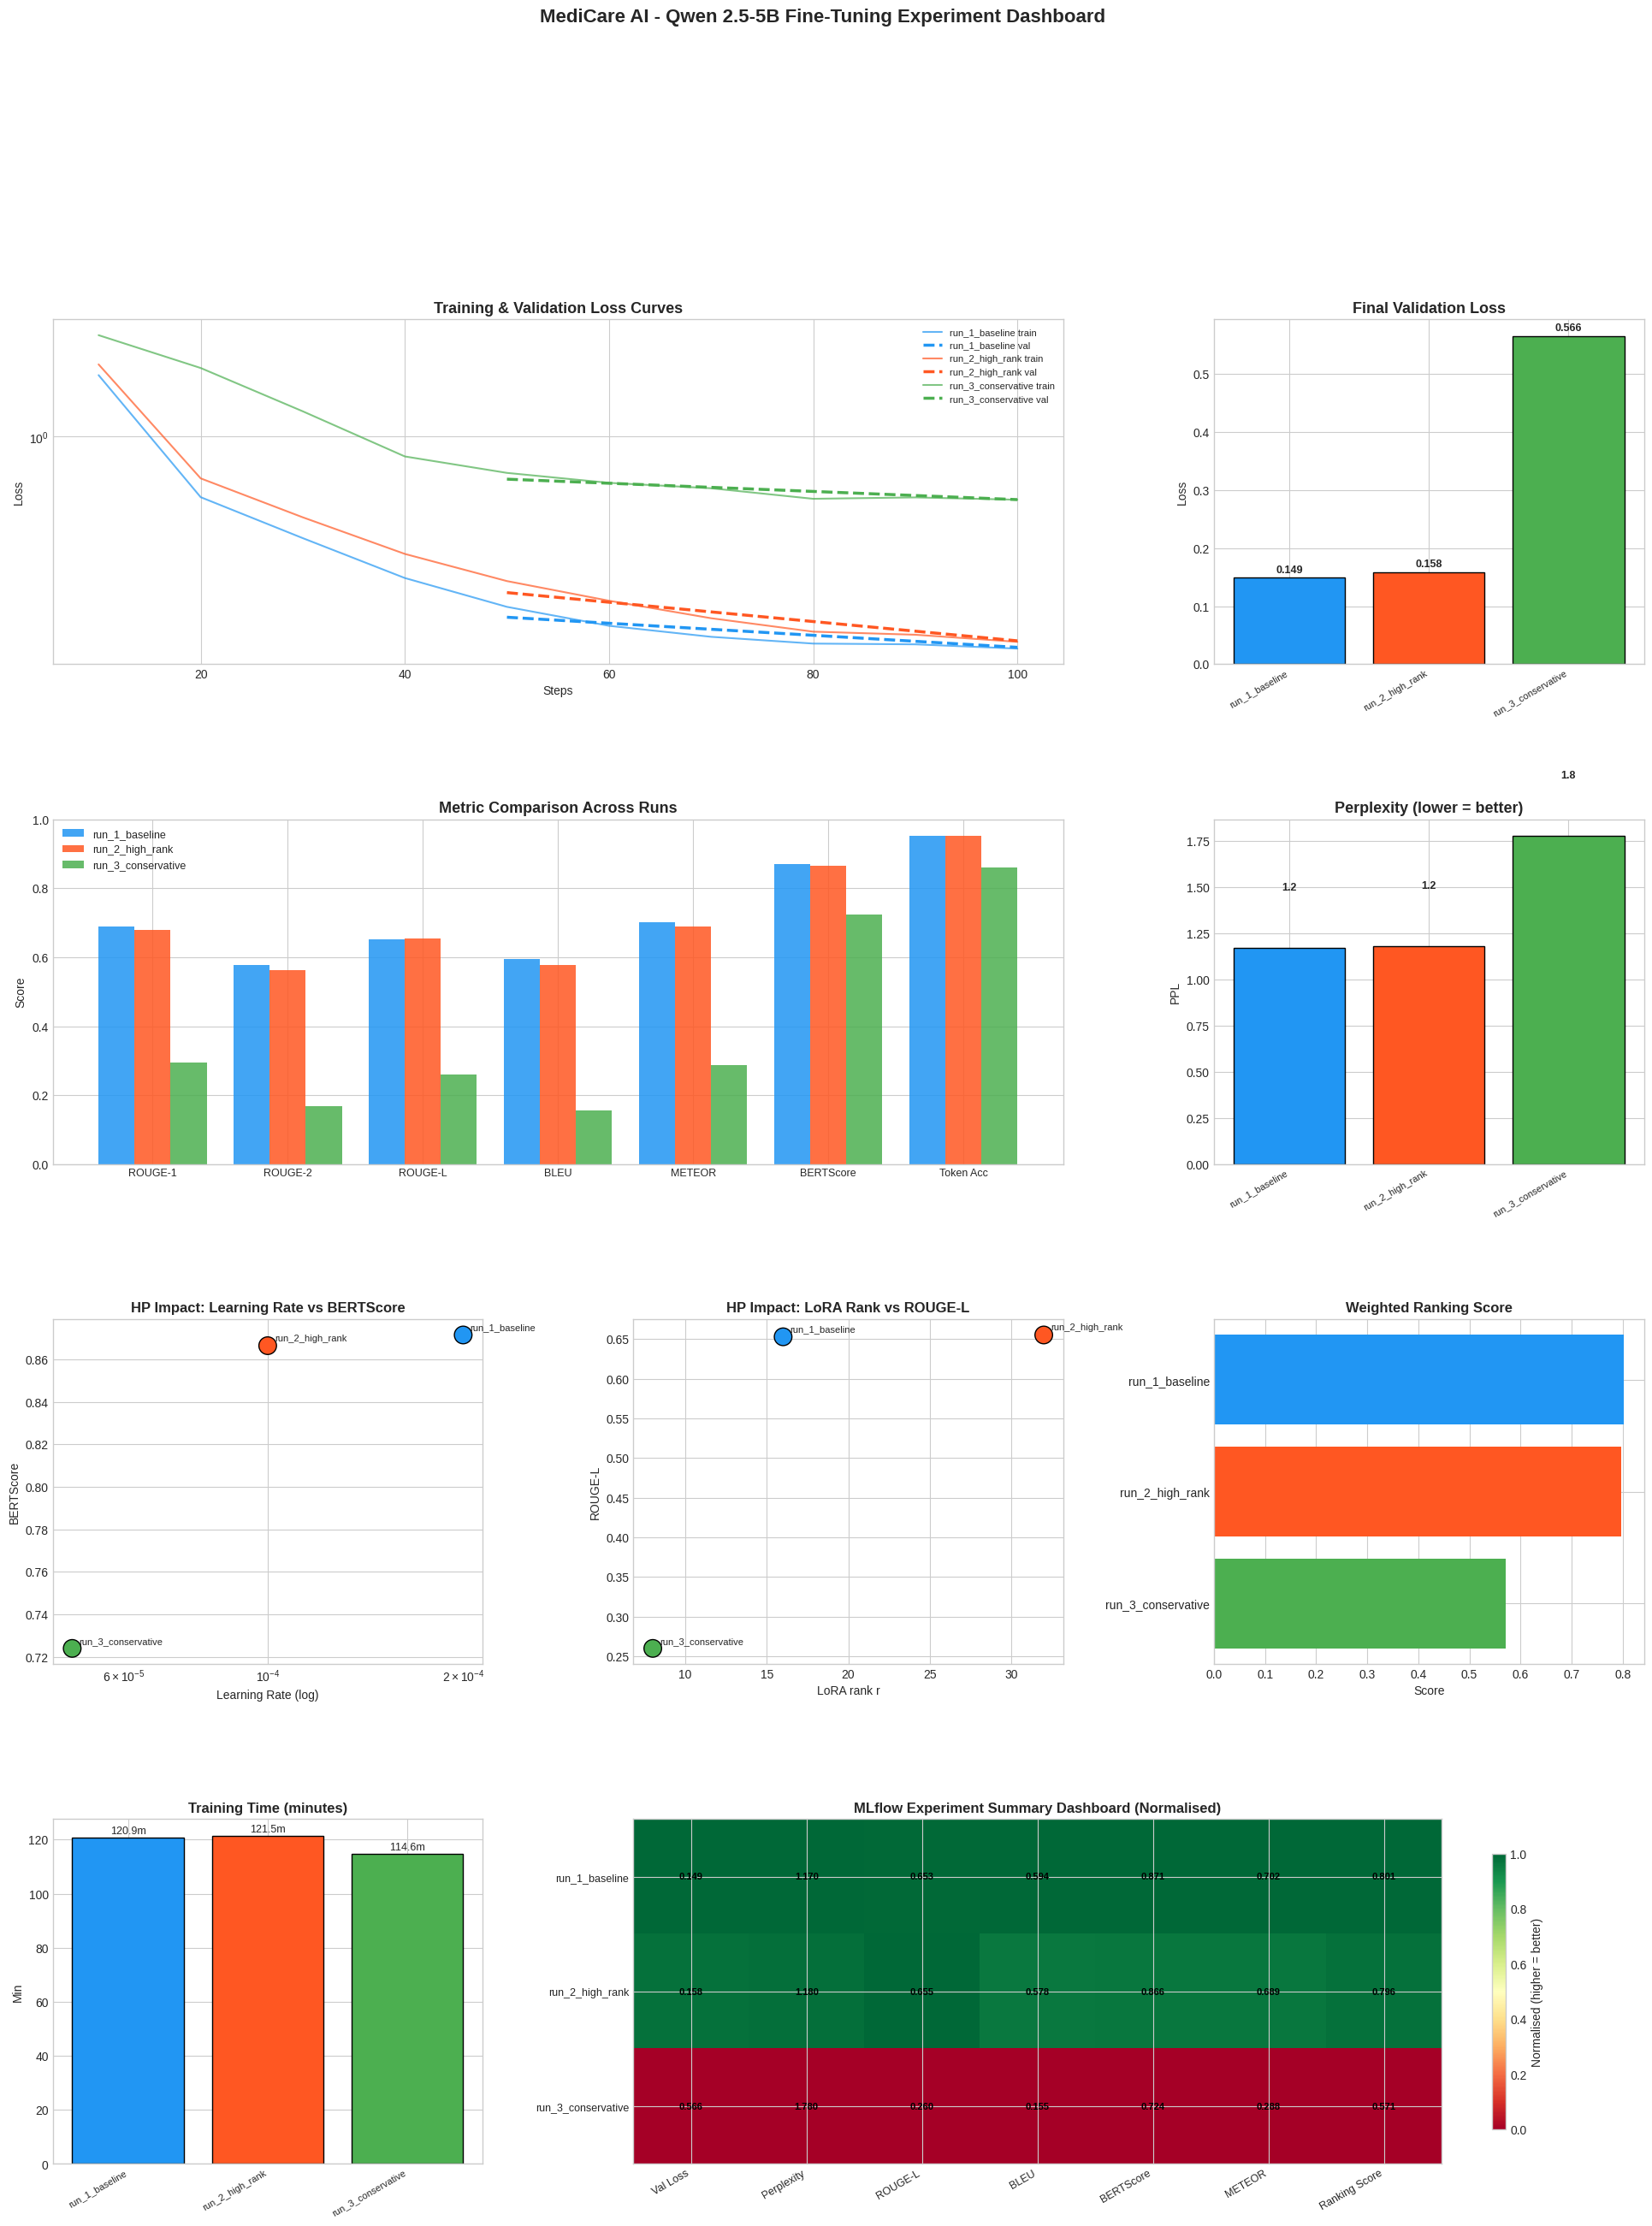

Dashboard saved: experiment_dashboard.png


In [16]:
def plot_dashboard(all_results: List[Dict], leaderboard_df: pd.DataFrame) -> None:
    plt.style.use("seaborn-v0_8-whitegrid")
    COLORS = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"]
    fig = plt.figure(figsize=(24, 28))
    gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)
    run_names = [r["run_name"] for r in all_results]

    # 1. Loss curves
    ax = fig.add_subplot(gs[0, :2])
    for i, r in enumerate(all_results):
        hist    = r.get("train_history", [])
        t_steps = [h["step"] for h in hist if "loss" in h and "eval_loss" not in h]
        t_loss  = [h["loss"] for h in hist if "loss" in h and "eval_loss" not in h]
        e_steps = [h["step"] for h in hist if "eval_loss" in h]
        e_loss  = [h["eval_loss"] for h in hist if "eval_loss" in h]
        c = COLORS[i % len(COLORS)]
        if t_steps: ax.plot(t_steps, t_loss, c=c, lw=1.5, alpha=0.7, label=f"{r['run_name']} train")
        if e_steps: ax.plot(e_steps, e_loss, c=c, lw=2.5, ls="--", label=f"{r['run_name']} val")
    ax.set_title("Training & Validation Loss Curves", fontsize=13, fontweight="bold")
    ax.set_xlabel("Steps"); ax.set_ylabel("Loss"); ax.legend(fontsize=8); ax.set_yscale("log")

    # 2. Final val loss
    ax = fig.add_subplot(gs[0, 2])
    vlosses = [r["val_loss"] for r in all_results]
    bars = ax.bar(range(len(run_names)), vlosses, color=COLORS[:len(run_names)], edgecolor="k")
    ax.set_xticks(range(len(run_names))); ax.set_xticklabels(run_names, rotation=30, ha="right", fontsize=8)
    ax.set_title("Final Validation Loss", fontsize=13, fontweight="bold"); ax.set_ylabel("Loss")
    for bar, v in zip(bars, vlosses):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    # 3. Metric comparison
    ax = fig.add_subplot(gs[1, :2])
    metric_cols = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore","Token Acc"]
    x = np.arange(len(metric_cols)); w = 0.8 / len(all_results)
    for i, r in enumerate(all_results):
        vals = [leaderboard_df.loc[leaderboard_df["Run"]==r["run_name"], mc].values[0] for mc in metric_cols]
        ax.bar(x + i*w, vals, w, label=r["run_name"], color=COLORS[i], alpha=0.85)
    ax.set_xticks(x + w*(len(all_results)-1)/2); ax.set_xticklabels(metric_cols, fontsize=9)
    ax.set_title("Metric Comparison Across Runs", fontsize=13, fontweight="bold")
    ax.set_ylabel("Score"); ax.legend(fontsize=9); ax.set_ylim(0, 1)

    # 4. Perplexity
    ax = fig.add_subplot(gs[1, 2])
    ppls = [r["perplexity"] for r in all_results]
    bars = ax.bar(range(len(run_names)), ppls, color=COLORS[:len(run_names)], edgecolor="k")
    ax.set_xticks(range(len(run_names))); ax.set_xticklabels(run_names, rotation=30, ha="right", fontsize=8)
    ax.set_title("Perplexity (lower = better)", fontsize=13, fontweight="bold"); ax.set_ylabel("PPL")
    for bar, v in zip(bars, ppls):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f"{v:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    # 5. LR vs BERTScore
    ax = fig.add_subplot(gs[2, 0])
    lrs  = [r["config"]["learning_rate"] for r in all_results]
    bscs = [r.get("val_bert_score", 0)   for r in all_results]
    ax.scatter(lrs, bscs, c=COLORS[:len(all_results)], s=220, zorder=5, edgecolors="k")
    for i, r in enumerate(all_results):
        ax.annotate(r["run_name"], (lrs[i], bscs[i]), xytext=(6,4), textcoords="offset points", fontsize=8)
    ax.set_xscale("log"); ax.set_title("HP Impact: Learning Rate vs BERTScore", fontsize=12, fontweight="bold")
    ax.set_xlabel("Learning Rate (log)"); ax.set_ylabel("BERTScore")

    # 6. LoRA rank vs ROUGE-L
    ax = fig.add_subplot(gs[2, 1])
    lora_rs = [r["config"]["lora_r"]   for r in all_results]
    rL_vals = [r.get("val_rougeL", 0)  for r in all_results]
    ax.scatter(lora_rs, rL_vals, c=COLORS[:len(all_results)], s=220, zorder=5, edgecolors="k")
    for i, r in enumerate(all_results):
        ax.annotate(r["run_name"], (lora_rs[i], rL_vals[i]), xytext=(6,4), textcoords="offset points", fontsize=8)
    ax.set_title("HP Impact: LoRA Rank vs ROUGE-L", fontsize=12, fontweight="bold")
    ax.set_xlabel("LoRA rank r"); ax.set_ylabel("ROUGE-L")

    # 7. Ranking score
    ax = fig.add_subplot(gs[2, 2])
    scores = [compute_ranking_score(r) for r in all_results]
    idx    = np.argsort(scores)[::-1]
    ax.barh([run_names[i] for i in idx], [scores[i] for i in idx], color=[COLORS[i] for i in idx])
    ax.set_title("Weighted Ranking Score", fontsize=12, fontweight="bold"); ax.set_xlabel("Score"); ax.invert_yaxis()

    # 8. Training time
    ax = fig.add_subplot(gs[3, 0])
    times = [r["training_time"] / 60 for r in all_results]
    bars  = ax.bar(range(len(run_names)), times, color=COLORS[:len(run_names)], edgecolor="k")
    ax.set_xticks(range(len(run_names))); ax.set_xticklabels(run_names, rotation=30, ha="right", fontsize=8)
    ax.set_title("Training Time (minutes)", fontsize=12, fontweight="bold"); ax.set_ylabel("Min")
    for bar, v in zip(bars, times):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f"{v:.1f}m", ha="center", va="bottom", fontsize=9)

    # 9. MLflow heatmap
    ax = fig.add_subplot(gs[3, 1:])
    hm_cols = ["Val Loss","Perplexity","ROUGE-L","BLEU","BERTScore","METEOR","Ranking Score"]
    hm_data = leaderboard_df[hm_cols].values.astype(float)
    hm_norm = np.zeros_like(hm_data)
    for j in range(hm_data.shape[1]):
        col = hm_data[:, j]; lo, hi = col.min(), col.max()
        if hi > lo:
            hm_norm[:, j] = (col - lo) / (hi - lo)
            if hm_cols[j] in ("Val Loss","Perplexity"):
                hm_norm[:, j] = 1 - hm_norm[:, j]
    im = ax.imshow(hm_norm, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(hm_cols))); ax.set_xticklabels(hm_cols, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(all_results))); ax.set_yticklabels([r["run_name"] for r in all_results], fontsize=9)
    ax.set_title("MLflow Experiment Summary Dashboard (Normalised)", fontsize=12, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8, label="Normalised (higher = better)")
    for i in range(hm_norm.shape[0]):
        for j in range(hm_norm.shape[1]):
            ax.text(j, i, f"{hm_data[i,j]:.3f}", ha="center", va="center", fontsize=8, color="black", fontweight="bold")

    plt.suptitle("MediCare AI - Qwen 2.5-5B Fine-Tuning Experiment Dashboard", fontsize=16, fontweight="bold", y=1.01)
    plt.savefig("experiment_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Dashboard saved: experiment_dashboard.png")
    with mlflow.start_run(run_name="visualizations"):
        mlflow.log_artifact("experiment_dashboard.png")

plot_dashboard(all_results, leaderboard_df)


## Cell 16 - Select and Register Best Model

In [17]:
def select_best_run(all_results: List[Dict]) -> Dict:
    return max(all_results, key=compute_ranking_score)

best_result = select_best_run(all_results)
best_run_name = best_result["run_name"]
best_score = compute_ranking_score(best_result)
print("BEST RUN:", best_run_name)
print(f"  Ranking Score : {best_score:.4f}")
print(f"  Val Loss      : {best_result['val_loss']:.4f}")
print(f"  Perplexity    : {best_result['perplexity']:.2f}")
print(f"  BERTScore     : {best_result.get('val_bert_score', 0):.4f}")
print(f"  ROUGE-L       : {best_result.get('val_rougeL', 0):.4f}")

# The best model/adapter is already loaded as `model` and `tokenizer`
# after run_all_experiments — reload from checkpoint if needed
best_checkpoint = best_result.get("best_checkpoint")
if best_checkpoint and os.path.isdir(best_checkpoint):
    print(f"\nReloading adapter from: {best_checkpoint}")
    model.load_adapter(best_checkpoint)
    print("Adapter reloaded.")
else:
    print("\nUsing in-memory model (checkpoint path not available or not yet saved).")

# Register best run in MLflow Model Registry
model_name_registry = "MediCare-Qwen25-5B-Best"
with mlflow.start_run(run_id=best_result["run_id"]):
    run_uri = f"runs:/{best_result['run_id']}/model"
    try:
        mlflow.register_model(run_uri, model_name_registry)
        print(f"\nRegistered best model in MLflow as: {model_name_registry}")
    except Exception as e:
        print(f"\nMLflow model registration skipped: {e}")

print("\nBest model ready for test evaluation.")


BEST RUN: run_1_baseline
  Ranking Score : 0.8012
  Val Loss      : 0.1490
  Perplexity    : 1.17
  BERTScore     : 0.8714
  ROUGE-L       : 0.6527

Using in-memory model (checkpoint path not available or not yet saved).

MLflow model registration skipped: Unable to find a logged_model with artifact_path model under run 0edd2fba21e940828727f1966537467b

Best model ready for test evaluation.


Successfully registered model 'MediCare-Qwen25-5B-Best'.


In [29]:
# Reload best model from saved checkpoint
best_ckpt = best_result["checkpoint_path"]  # ./checkpoints/run_1_baseline/final_adapter
print(f"Loading adapter from: {best_ckpt}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)
model = PeftModel.from_pretrained(model, best_ckpt)
FastLanguageModel.for_inference(model)
print("Model reloaded and ready.")

Loading adapter from: ./checkpoints/run_1_baseline/final_adapter
==((====))==  Unsloth 2026.6.7: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model reloaded and ready.


## Cell 17 - Test Set Evaluation

In [30]:
print("Evaluating best model on held-out test set ...")
print(f"Test size: {len(test_data)} examples\n")

_test_samples = test_data[:300]

print("  Generating predictions on test set...")
_test_preds  = generate_predictions(model, tokenizer, _test_samples, max_new_tokens=200)
_test_truths = [item["ground_truth"] for item in _test_samples]

print("  Computing NLP metrics...")
_nlp = compute_all_metrics(_test_preds, _test_truths)

print("  Computing perplexity...")
_test_texts = [tokenizer.apply_chat_template(item["messages"], tokenize=False,
               add_generation_prompt=False) for item in _test_samples[:60]]
_ppl = compute_perplexity(model, tokenizer, _test_texts)

print("  Computing token accuracy...")
_tok_acc = compute_token_accuracy(model, tokenizer, _test_samples, max_samples=30)

test_results = {
    "rouge1":         _nlp.get("rouge1",      0.0),
    "rouge2":         _nlp.get("rouge2",      0.0),
    "rougeL":         _nlp.get("rougeL",      0.0),
    "bleu":           _nlp.get("bleu",        0.0),
    "meteor":         _nlp.get("meteor",      0.0),
    "bert_score":     _nlp.get("bert_score",  0.0),
    "exact_match":    _nlp.get("exact_match", 0.0),
    "perplexity":     _ppl,
    "token_accuracy": _tok_acc,
}

print("\nTEST SET RESULTS")
print("="*50)
for k, v in test_results.items():
    print(f"  {k:<22}: {v:.4f}")

with mlflow.start_run(run_id=best_result["run_id"], nested=True):
    for k, v in test_results.items():
        mlflow.log_metric(f"test_{k}", v)
print("\nTest metrics logged to MLflow.")

test_df = pd.DataFrame([{"metric": k, "value": round(v, 4)} for k, v in test_results.items()])
test_df.to_csv("test_evaluation.csv", index=False)
print("Saved: test_evaluation.csv")

Evaluating best model on held-out test set ...
Test size: 5400 examples

  Generating predictions on test set...


Generating:   0%|          | 0/300 [00:00<?, ?it/s]

  Computing NLP metrics...
   ROUGE: R1=0.7585  R2=0.6710  RL=0.7356
   BLEU: 0.6674
   METEOR: 0.7596


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   BERTScore F1: 0.8975
   Exact Match: 0.3300
  Computing perplexity...
  Computing token accuracy...

TEST SET RESULTS
  rouge1                : 0.7585
  rouge2                : 0.6710
  rougeL                : 0.7356
  bleu                  : 0.6674
  meteor                : 0.7596
  bert_score            : 0.8975
  exact_match           : 0.3300
  perplexity            : 1.1691
  token_accuracy        : 0.9527

Test metrics logged to MLflow.
Saved: test_evaluation.csv


## Cell 18 - Inference Examples

In [31]:
SYSTEM_PROMPT = (
    "You are MediCare AI, a helpful medical supplies assistant for an Egyptian e-commerce platform. "
    "You assist customers with product inquiries, order tracking, recommendations, returns, payments, "
    "and support. You are fluent in both English and Egyptian Arabic. "
    "Always be polite, accurate, and helpful."
)

INFERENCE_EXAMPLES = [
    {
        "id": 1, "language": "English", "intent": "product_inquiry",
        "user": "Hello! Do you have digital blood pressure monitors available? I need one for home use."
    },
    {
        "id": 2, "language": "Arabic", "intent": "product_search",
        "user": "عايز اشتري جهاز قياس السكر في البيت، عندكم ايه؟"
    },
    {
        "id": 3, "language": "English", "intent": "order_tracking",
        "user": "I placed an order 3 days ago for a wheelchair. Can you tell me where my order is now?"
    },
    {
        "id": 4, "language": "Arabic", "intent": "complaint",
        "user": "الجهاز اللي اشتريته من عندكم وصلني تالف. عايز احله ازاي؟"
    },
    {
        "id": 5, "language": "English", "intent": "recommendation_request",
        "user": "My father is diabetic and has trouble walking. What medical supplies would you recommend for him?"
    },
    {
        "id": 6, "language": "Arabic", "intent": "payment",
        "user": "ممكن اعرف طرق الدفع المتاحة عندكم؟ بقدر ادفع بفيزا؟"
    },
    {
        "id": 7, "language": "English", "intent": "return",
        "user": "I received the wrong size nebulizer mask. How can I return it and get the correct one?"
    },
    {
        "id": 8, "language": "Arabic", "intent": "greeting",
        "user": "اهلا، انا محتاج مساعدة في اختيار جهاز قياس الضغط المناسب."
    },
]

print(f"Prepared {len(INFERENCE_EXAMPLES)} inference examples:")
for ex in INFERENCE_EXAMPLES:
    lang_tag = f"[{ex['language']}]"
    intent_tag = f"[{ex['intent']}]"
    print(f"  {ex['id']}. {lang_tag:<10} {intent_tag:<30} {ex['user'][:60]}...")


Prepared 8 inference examples:
  1. [English]  [product_inquiry]              Hello! Do you have digital blood pressure monitors available...
  2. [Arabic]   [product_search]               عايز اشتري جهاز قياس السكر في البيت، عندكم ايه؟...
  3. [English]  [order_tracking]               I placed an order 3 days ago for a wheelchair. Can you tell ...
  4. [Arabic]   [complaint]                    الجهاز اللي اشتريته من عندكم وصلني تالف. عايز احله ازاي؟...
  5. [English]  [recommendation_request]       My father is diabetic and has trouble walking. What medical ...
  6. [Arabic]   [payment]                      ممكن اعرف طرق الدفع المتاحة عندكم؟ بقدر ادفع بفيزا؟...
  7. [English]  [return]                       I received the wrong size nebulizer mask. How can I return i...
  8. [Arabic]   [greeting]                     اهلا، انا محتاج مساعدة في اختيار جهاز قياس الضغط المناسب....


## Cell 19 - Run Inference

In [32]:
def run_inference(model, tokenizer, system_prompt: str, user_message: str,
                  max_new_tokens: int = 512, temperature: float = 0.7) -> str:
    messages = [
        {"role": "system",    "content": system_prompt},
        {"role": "user",      "content": user_message},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )
    # Decode only newly generated tokens
    new_ids = generated_ids[0][model_inputs.input_ids.shape[-1]:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


print("Running inference on 8 unseen examples ...\n")
inference_results = []
model.eval()

for ex in INFERENCE_EXAMPLES:
    print(f"[{ex['id']}/8] {ex['language']} | intent: {ex['intent']}")
    response = run_inference(model, tokenizer, SYSTEM_PROMPT, ex["user"])
    inference_results.append({
        "id":       ex["id"],
        "language": ex["language"],
        "intent":   ex["intent"],
        "user":     ex["user"],
        "response": response,
    })
    print(f"  User    : {ex['user'][:80]}...")
    print(f"  Response: {response[:120]}...")
    print()

print(f"Inference complete. {len(inference_results)} responses generated.")


Running inference on 8 unseen examples ...

[1/8] English | intent: product_inquiry
  User    : Hello! Do you have digital blood pressure monitors available? I need one for hom...
  Response: 👋 Sure, Maha! Available models include:

1. **Digital Blood Pressure Monitor** — 40 reviews, 4.6/5 ⭐
2. **Stethoscope Cl...

[2/8] Arabic | intent: product_search
  User    : عايز اشتري جهاز قياس السكر في البيت، عندكم ايه؟...
  Response: ✅ طبعاً يا ريت! **Blood Glucose Meter** من ديجيتال سيستمز:

• 5-second result
• 500-reading memory
• no-coding technolog...

[3/8] English | intent: order_tracking
  User    : I placed an order 3 days ago for a wheelchair. Can you tell me where my order is...
  Response: Sure, I can help track your order, Shaimaa!

Please share the order reference number or the name and address associated ...

[4/8] Arabic | intent: complaint
  User    : الجهاز اللي اشتريته من عندكم وصلني تالف. عايز احله ازاي؟...
  Response: أنا آسف متابعتك personal. سأساعدك في إرجاع أو تبديل الجه

## Cell 20 - Display Inference Results

In [33]:
print("INFERENCE RESULTS - MediCare AI")
print("="*100)
for r in inference_results:
    print(f"\nExample {r['id']}  |  Language: {r['language']}  |  Intent: {r['intent']}")
    print("-"*100)
    print(f"User     : {r['user']}")
    print(f"Response : {r['response']}")
    print("="*100)

# Save results to CSV and log to MLflow
inf_df = pd.DataFrame(inference_results)
inf_df.to_csv("inference_results.csv", index=False, encoding="utf-8")
print("\nSaved: inference_results.csv")

with mlflow.start_run(run_name="inference_demo"):
    mlflow.log_artifact("inference_results.csv")
    mlflow.log_param("num_examples", len(inference_results))
    mlflow.log_param("languages", "English, Arabic")
    mlflow.log_param("intents_covered",
                     ", ".join(set(r["intent"] for r in inference_results)))
    print("Inference results logged to MLflow.")


INFERENCE RESULTS - MediCare AI

Example 1  |  Language: English  |  Intent: product_inquiry
----------------------------------------------------------------------------------------------------
User     : Hello! Do you have digital blood pressure monitors available? I need one for home use.
Response : 👋 Sure, Maha! Available models include:

1. **Digital Blood Pressure Monitor** — 40 reviews, 4.6/5 ⭐
2. **Stethoscope Classic** — 300+ units sold
3. **Ear & Forehead Thermometer** — 200+ reviews, 4.8/5 ⭐

Which interests you? Want more info on the Digital Blood Pressure Monitor?

Example 2  |  Language: Arabic  |  Intent: product_search
----------------------------------------------------------------------------------------------------
User     : عايز اشتري جهاز قياس السكر في البيت، عندكم ايه؟
Response : ✅ طبعاً يا ريت! **Blood Glucose Meter** من ديجيتال سيستمز:

• 5-second result
• 500-reading memory
• no-coding technology
• meal tracking
• doctor share feature

التقييم: ⭐⭐⭐⭐½

المتوفر ب

## Cell 21 - Final Summary

In [35]:
print("="*80)
print("MEDICARE AI - QWEN 2.5-5B FINE-TUNING SUMMARY")
print("="*80)

print("\nExperiment Overview:")
print(f"  Model         : Qwen 2.5-5B-Instruct (QLoRA 4-bit via Unsloth)")
print(f"  Dataset       : ~54K examples | 18 intents | EN + AR")
print(f"  Split         : 80/10/10 (train/val/test)")
print(f"  Runs          : {len(all_results)}")
print(f"  MLflow URI    : sqlite:///mlflow.db")
print(f"  Experiment    : {MLFLOW_EXPERIMENT}")

print("\nLeaderboard (ranked by weighted score):")
print(leaderboard_df[["Rank","Run","Ranking Score","Val Loss","Perplexity",
                       "ROUGE-L","BLEU","BERTScore"]].to_string(index=False))

print(f"\nBest Run      : {best_run_name}")
print(f"Ranking Score : {best_score:.4f}")

print("\nTest Set Evaluation (best model):")
for k, v in test_results.items():
    print(f"  {k:<22}: {v:.4f}")

print("\nInference: 8 unseen examples (4 EN + 4 AR, 8 different intents) - COMPLETED")

print("\nArtifacts saved:")
artifacts = [
    "leaderboard.csv",
    "experiment_dashboard.png",
    "test_evaluation.csv",
    "inference_results.csv",
]
for a in artifacts:
    exists = "[OK]" if os.path.isfile(a) else "[MISSING]"
    print(f"  {exists}  {a}")

print("\nAll MLflow runs logged to: sqlite:///mlflow.db")
print("="*80)
print("Fine-tuning pipeline complete.")
print("="*80)


MEDICARE AI - QWEN 2.5-5B FINE-TUNING SUMMARY

Experiment Overview:
  Model         : Qwen 2.5-5B-Instruct (QLoRA 4-bit via Unsloth)
  Dataset       : ~54K examples | 18 intents | EN + AR
  Split         : 80/10/10 (train/val/test)
  Runs          : 3
  MLflow URI    : sqlite:///mlflow.db
  Experiment    : MediCare_Qwen25_7B_Finetuning

Leaderboard (ranked by weighted score):
 Rank                Run  Ranking Score  Val Loss  Perplexity  ROUGE-L   BLEU  BERTScore
    1     run_1_baseline         0.8012    0.1490        1.17   0.6527 0.5940     0.8714
    2    run_2_high_rank         0.7965    0.1580        1.18   0.6550 0.5781     0.8664
    3 run_3_conservative         0.5713    0.5657        1.78   0.2601 0.1552     0.7240

Best Run      : run_1_baseline
Ranking Score : 0.8012

Test Set Evaluation (best model):
  rouge1                : 0.7585
  rouge2                : 0.6710
  rougeL                : 0.7356
  bleu                  : 0.6674
  meteor                : 0.7596
  bert_sco

In [37]:
import shutil, os


files = [
    "leaderboard.csv",
    "experiment_dashboard.png", 
    "test_evaluation.csv",
    "inference_results.csv",
    "mlflow.db",
]

os.makedirs("results", exist_ok=True)
for f in files:
    if os.path.exists(f):
        shutil.copy(f, f"results/{f}")
        print(f"  copied: {f}")

shutil.make_archive("medicare_results", "zip", "results")
print("\nDone: medicare_results.zip")

from IPython.display import FileLink
FileLink("medicare_results.zip")

  copied: leaderboard.csv
  copied: experiment_dashboard.png
  copied: test_evaluation.csv
  copied: inference_results.csv
  copied: mlflow.db

Done: medicare_results.zip


/kaggle/working/medicare_results.zip

In [40]:
import shutil
from IPython.display import FileLink

best_ckpt = best_result["checkpoint_path"]  

shutil.make_archive("best_model_adapter", "zip", best_ckpt)
print("Done")
FileLink("best_model_adapter.zip")

Done


/kaggle/working/best_model_adapter.zip

In [48]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
runs = mlflow.search_runs(search_all_experiments=True)
print(f"Total runs: {len(runs)}")
print(runs[["run_id", "status", "tags.mlflow.runName"]].to_string())

Total runs: 6
                             run_id    status tags.mlflow.runName
0  3ac372fbbeae4ac0b53b991957bac6dd  FINISHED      inference_demo
1  8ab9dacf58a6457ea47853450feabc1f  FINISHED      visualizations
2  92d9055c69064c199ff2978a4196379a  FINISHED         leaderboard
3  58d004fe50fd4f9c9a49350a8962c925  FINISHED  run_3_conservative
4  14d14c574ff34cd9a9245c9935ee5eb9  FINISHED     run_2_high_rank
5  0edd2fba21e940828727f1966537467b  FINISHED      run_1_baseline
